<a href="https://colab.research.google.com/github/shibbolithic/AmazonMLhack/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##loading the dataset

In [2]:
pip install opendatasets --upgrade --quiet

In [3]:
# kaggle key = 48f24485c84863ac20533f43087cca3f
import opendatasets as od
download_url = 'https://www.kaggle.com/datasets/arnavsharma45/quora-insincere-questions-dataset'
od.download(download_url)

Skipping, found downloaded files in "./quora-insincere-questions-dataset" (use force=True to force download)


In [4]:
import os


In [5]:
os.environ['KAGGLE_CONFIG_DIR']='.'

In [6]:
train_fname='/content/quora-insincere-questions-dataset/train.csv'

In [7]:
pip install gensim

In [8]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from nltk.tokenize import RegexpTokenizer

In [9]:
raw_df= pd.read_csv(train_fname)
raw_df

,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0
...,...,...,...
1306117,ffffcc4e2331aaf1e41e,What other technical skills do you need as a c...,0
1306118,ffffd431801e5a2f4861,Does MS in ECE have good job prospects in USA ...,0
1306119,ffffd48fb36b63db010c,Is foam insulation toxic?,0
1306120,ffffec519fa37cf60c78,How can one start a research project based on ...,0


In [10]:


# 1. Load dataset
df = pd.read_csv(train_fname)
df = df[['question_text', 'target']].dropna()
X_text = df['question_text'].values
y = df['target'].values

# 2. Fast tokenization (no punkt needed)
tokenizer = RegexpTokenizer(r'\w+')
sentences = [tokenizer.tokenize(q.lower()) for q in X_text]

In [11]:
raw_df= pd.read_csv(train_fname)
raw_df

,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0
...,...,...,...
1306117,ffffcc4e2331aaf1e41e,What other technical skills do you need as a c...,0
1306118,ffffd431801e5a2f4861,Does MS in ECE have good job prospects in USA ...,0
1306119,ffffd48fb36b63db010c,Is foam insulation toxic?,0
1306120,ffffec519fa37cf60c78,How can one start a research project based on ...,0


In [12]:
sincere_df = raw_df[raw_df.target == 0]

In [13]:
insincere_df = raw_df[raw_df.target == 1]

##preprocessing


In [14]:
pip install swifter

In [15]:
import pandas as pd
import re
import nltk
import swifter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [17]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # URLs
    text = re.sub(r"[^a-z']", " ", text)         # keep letters
    text = re.sub(r"\s+", " ", text).strip()     # normalize spaces
    return text


In [18]:
def fast_lemmatize(text):
    words = text.split()
    return " ".join(
        [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    )


In [19]:
raw_df["clean_text"] = raw_df["question_text"].swifter.apply(clean_text)
raw_df["lemmatized_text"] = raw_df["clean_text"].swifter.apply(fast_lemmatize)


Pandas Apply:   0%|          | 0/1306122 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/1306122 [00:00<?, ?it/s]

In [20]:
raw_df[["question_text", "clean_text", "lemmatized_text"]].head()


,question_text,clean_text,lemmatized_text
0,How did Quebec nationalists see their province...,how did quebec nationalists see their province...,quebec nationalist see province nation
1,"Do you have an adopted dog, how would you enco...",do you have an adopted dog how would you encou...,adopted dog would encourage people adopt shop
2,Why does velocity affect time? Does velocity a...,why does velocity affect time does velocity af...,velocity affect time velocity affect space geo...
3,How did Otto von Guericke used the Magdeburg h...,how did otto von guericke used the magdeburg h...,otto von guericke used magdeburg hemisphere
4,Can I convert montra helicon D to a mountain b...,can i convert montra helicon d to a mountain b...,convert montra helicon mountain bike changing ...


In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    raw_df['lemmatized_text'], raw_df['target'], test_size=0.2, random_state=42
)


##feature Engineering

###🧩 Step 1: TF-IDF Features (Optimized)[link text](https://)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf_word = TfidfVectorizer(
    max_features=20000,        # lower dimension
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5, max_df=0.8,
    stop_words='english'
)

tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=10000
)

X_word = tfidf_word.fit_transform(raw_df["lemmatized_text"])
X_char = tfidf_char.fit_transform(raw_df["lemmatized_text"])

X_tfidf = hstack([X_word, X_char]).tocsr()


###🧩 Step 2: Meta Features (Fast + Simple)

In [23]:
import numpy as np
import pandas as pd
import re

def quick_meta(text):
    length = len(text)
    words = text.split()
    return pd.Series([
        len(words),                      # num_words
        length / (len(words)+1),         # avg word len
        len(re.findall(r"[!?.,]", text)) # num punct
    ])

meta_df = raw_df["lemmatized_text"].apply(quick_meta)
meta_df.columns = ["num_words", "avg_word_len", "num_punct"]


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_meta = scaler.fit_transform(meta_df)


In [25]:
from scipy.sparse import csr_matrix
X_meta_sparse = csr_matrix(X_meta)
X_final = hstack([X_tfidf, X_meta_sparse]).tocsr()


###🧩 Step 3: Word2Vec Embeddings (Optimized via Pre-trained Model)

In [26]:
import gensim.downloader as api
w2v = api.load("glove-wiki-gigaword-50")  # 66MB only


In [27]:
from sklearn.feature_extraction.text import HashingVectorizer

vectorizer = HashingVectorizer(
    n_features=2**18,     # ~260k features
    alternate_sign=False,
    ngram_range=(1,2),
    norm='l2'
)

X_hash = vectorizer.transform(raw_df["lemmatized_text"])


In [28]:
import joblib
joblib.dump(X_tfidf, "tfidf_sparse.pkl", compress=0)
joblib.dump(X_meta, "meta_features.pkl", compress=0)


['meta_features.pkl']

In [29]:
!ls -lh /content/tfidf_sparse.pkl


-rw-r--r-- 1 root root 1.3G Oct 26 19:12 /content/tfidf_sparse.pkl


In [30]:
import joblib
from scipy.sparse import csr_matrix, hstack

# Load the saved features
X_tfidf = joblib.load("tfidf_sparse.pkl", mmap_mode='r')
X_meta = joblib.load("meta_features.pkl")

# Convert meta features to sparse matrix if not already
if not isinstance(X_meta, csr_matrix):
    X_meta_sparse = csr_matrix(X_meta)
else:
    X_meta_sparse = X_meta

# Combine TF-IDF and meta features
X_final = hstack([X_tfidf, X_meta_sparse]).tocsr()

print("Loaded and combined features.")
print("Shape of combined features:", X_final.shape)

Loaded and combined features.
Shape of combined features: (1306122, 30003)


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming raw_df is already loaded from your previous execution
# If not, you might need to load it again:
# train_fname = '/content/quora-insincere-questions-dataset/train.csv'
# raw_df = pd.read_csv(train_fname)

# Split the data
# Ensure you use the target column from the original dataframe
X_train, X_val, y_train, y_val = train_test_split(
    X_final, raw_df["target"], test_size=0.2, random_state=42, stratify=raw_df["target"]
)

print("Data split into training and validation sets.")
print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

Data split into training and validation sets.
Shape of X_train: (1044897, 30003)
Shape of X_val: (261225, 30003)
Shape of y_train: (1044897,)
Shape of y_val: (261225,)


### Retrain Models

In [32]:
import torch
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"GPU device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch CUDA available: True
GPU device: Tesla T4


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

# Load the saved Logistic Regression model if available, otherwise train
try:
    lr = joblib.load("model_logreg.pkl")
    print("Loaded saved Logistic Regression model.")
except FileNotFoundError:
    print("Saved Logistic Regression model not found. Training new model.")
    lr = LogisticRegression(
        C=2.0,
        max_iter=400,
        solver="saga",
        n_jobs=-1,
        class_weight="balanced"
    )
    lr.fit(X_train, y_train)
    joblib.dump(lr, "model_logreg.pkl", compress=0)
    print("Trained and saved Logistic Regression model.")

pred_lr = lr.predict_proba(X_val)[:, 1]
f1_lr = f1_score(y_val, (pred_lr > 0.5).astype(int))
roc_lr = roc_auc_score(y_val, pred_lr)
print(f"LogReg → F1: {f1_lr:.4f}, ROC-AUC: {roc_lr:.4f}")

Loaded saved Logistic Regression model.
LogReg → F1: 0.5145, ROC-AUC: 0.9500


In [34]:
import numpy as np
from scipy.sparse import issparse
import pandas as pd

def prepare_data(X_train, y_train, X_val, y_val, max_train_samples=30000, max_val_samples=5000):
    n_train = X_train.shape[0]
    n_val = X_val.shape[0]

    # Randomly sample training data
    if n_train > max_train_samples:
        indices = np.random.choice(n_train, max_train_samples, replace=False)

        if isinstance(X_train, pd.DataFrame):
            X_train = X_train.iloc[indices]
        elif issparse(X_train):
            X_train = X_train[indices, :]
        else:
            X_train = X_train[indices]

        y_train = np.array(y_train)[indices]

    # Randomly sample validation data
    if n_val > max_val_samples:
        indices = np.random.choice(n_val, max_val_samples, replace=False)

        if isinstance(X_val, pd.DataFrame):
            X_val = X_val.iloc[indices]
        elif issparse(X_val):
            X_val = X_val[indices, :]
        else:
            X_val = X_val[indices]

        y_val = np.array(y_val)[indices]

    return X_train, y_train, X_val, y_val


In [35]:
import lightgbm as lgb
import numpy as np
import gc

import lightgbm as lgb
import numpy as np
import gc

def train_lightgbm_memory_efficient(X_train, y_train, X_val, y_val, params=None, num_boost_round=1000, early_stopping_rounds=50):
    """
    Memory-optimized LightGBM training function with version-safe early stopping.
    Works with sparse or dense data, avoids high RAM usage.
    """
    if params is None:
        params = {
            "objective": "binary",
            "metric": "auc",
            "boosting_type": "gbdt",
            "learning_rate": 0.05,
            "num_leaves": 15,
            "max_depth": 6,
            "min_data_in_leaf": 20,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "n_jobs": 1,
            "verbose": -1,
            "max_bin": 128,
        }

    # Create LightGBM datasets
    train_data = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, free_raw_data=False)

    # Version-safe early stopping
    try:
        model = lgb.train(
            params=params,
            train_set=train_data,
            valid_sets=[train_data, val_data],
            valid_names=["train", "valid"],
            num_boost_round=num_boost_round,
            early_stopping_rounds=early_stopping_rounds,
            verbose_eval=100
        )
    except TypeError:
        # For LightGBM >= 4.0 (no early_stopping_rounds arg)
        model = lgb.train(
            params=params,
            train_set=train_data,
            valid_sets=[train_data, val_data],
            valid_names=["train", "valid"],
            num_boost_round=num_boost_round,
            callbacks=[
                lgb.early_stopping(early_stopping_rounds, verbose=True),
                lgb.log_evaluation(100)
            ],
        )

    # Cleanup
    del train_data, val_data
    gc.collect()

    return model



def predict_in_chunks(model, X, chunk_size=1000):
    """
    Predict in small chunks to reduce memory pressure.
    Works for both sparse and dense matrices.
    """
    preds = []
    n = X.shape[0]
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        preds.append(model.predict(X[start:end]))
        gc.collect()
    return np.concatenate(preds)


In [37]:
import os

if not os.path.exists("model_lgb.pkl"):
    X_train_opt, y_train_opt, X_val_opt, y_val_opt = prepare_data(X_train, y_train, X_val, y_val)
    lgb_model = train_lightgbm_memory_efficient(X_train_opt, y_train_opt, X_val_opt, y_val_opt)
    joblib.dump(lgb_model, "model_lgb.pkl", compress=0)
    print("✅ Trained and saved LightGBM model.")
else:
    lgb_model = joblib.load("model_lgb.pkl")
    print("✅ Loaded saved LightGBM model.")


pred_lgb = predict_in_chunks(lgb_model, X_val_opt, chunk_size=500)
f1_lgb = f1_score(y_val_opt, (pred_lgb > 0.5).astype(int))
roc_lgb = roc_auc_score(y_val_opt, pred_lgb)
print(f"✅ Optimized LightGBM → F1: {f1_lgb:.4f}, ROC-AUC: {roc_lgb:.4f}")

✅ Loaded saved LightGBM model.
✅ Optimized LightGBM → F1: 0.3065, ROC-AUC: 0.9095


In [ ]:
# import lightgbm as lgb
# from sklearn.metrics import f1_score, roc_auc_score
# import joblib

# params = {
#     "objective": "binary",
#     "metric": "auc",
#     "boosting_type": "gbdt",
#     "learning_rate": 0.05,
#     "num_leaves": 31,
#     "max_depth": -1,
#     "n_jobs": -1,
#     "verbose": -1
# }

# lgb_train = lgb.Dataset(X_train, label=y_train)
# lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

# # Load the saved LightGBM model if available, otherwise train
# try:
#     lgb_model = joblib.load("model_lgb.pkl")
#     print("Loaded saved LightGBM model.")
# except FileNotFoundError:
#     print("Saved LightGBM model not found. Training new model.")
#     lgb_model = lgb.train(
#         params,
#         lgb_train,
#         valid_sets=[lgb_train, lgb_val],
#         num_boost_round=500,
#         callbacks=[
#             lgb.early_stopping(stopping_rounds=30),
#             lgb.log_evaluation(period=100)  # Replaces verbose_eval
#         ]
#     )
#     joblib.dump(lgb_model, "model_lgb.pkl", compress=3)
#     print("Trained and saved LightGBM model.")

# pred_lgb = lgb_model.predict(X_val)
# f1_lgb = f1_score(y_val, (pred_lgb > 0.5).astype(int))
# roc_lgb = roc_auc_score(y_val, pred_lgb)
# print(f"LightGBM → F1: {f1_lgb:.4f}, ROC-AUC: {roc_lgb:.4f}")

In [38]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import f1_score, roc_auc_score
import joblib

try:
    nb = joblib.load("model_nb.pkl")
    print("Loaded saved Naive Bayes model.")
except FileNotFoundError:
    print("Saved Naive Bayes model not found. Training new model.")
    nb = BernoulliNB()  # or MultinomialNB(alpha=0.1)
    nb.fit(X_train, y_train)
    joblib.dump(nb, "model_nb.pkl", compress=0)
    print("Trained and saved Naive Bayes model.")

pred_nb = nb.predict_proba(X_val)[:, 1]
f1_nb = f1_score(y_val, (pred_nb > 0.5).astype(int))
roc_nb = roc_auc_score(y_val, pred_nb)
print(f"Naive Bayes → F1: {f1_nb:.4f}, ROC-AUC: {roc_nb:.4f}")


Saved Naive Bayes model not found. Training new model.
Trained and saved Naive Bayes model.
Naive Bayes → F1: 0.3975, ROC-AUC: 0.8890


### Ensemble Model

In [41]:
# Align other predictions and labels to the same subset used for LightGBM
n_val_opt = len(y_val_opt)

pred_lr_small = pred_lr[:n_val_opt]
pred_nb_small = pred_nb[:n_val_opt]
y_val_small = y_val[:n_val_opt]

pred_ensemble = (
    0.5 * pred_lr_small +
    0.3 * pred_lgb +
    0.2 * pred_nb_small
)

thresholds = np.arange(0.3, 0.7, 0.01)
f1_scores = [f1_score(y_val_small, (pred_ensemble > t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]


In [44]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

# Ensure pred_lr, pred_lgb, and pred_nb are available from previous cells

# pred_ensemble = (
#     0.5 * pred_lr +
#     0.3 * pred_lgb +
#     0.2 * pred_nb
# )

# thresholds = np.arange(0.3, 0.7, 0.01)
# f1_scores = [f1_score(y_val, (pred_ensemble > t).astype(int)) for t in thresholds]
# best_t = thresholds[np.argmax(f1_scores)]


# Save the ensemble predictions, weights, and best threshold
ensemble_data = {
    "weights": {"lr": 0.5, "lgb": 0.3, "nb": 0.2},
    "best_threshold": best_t,
    "pred_ensemble": pred_ensemble
}

joblib.dump(ensemble_data, "ensemble_model.pkl")

print(f"Best threshold for ensemble: {best_t:.2f}, F1: {max(f1_scores):.4f}")
print("Ensemble ROC-AUC:", roc_auc_score(y_val_small, pred_ensemble))


Best threshold for ensemble: 0.65, F1: 0.5749
Ensemble ROC-AUC: 0.937649203129203


In [45]:
f1_lr = f1_score(y_val, (pred_lr > 0.5).astype(int))
roc_lr = roc_auc_score(y_val, pred_lr)
print(f"LogReg → F1: {f1_lr:.4f}, ROC-AUC: {roc_lr:.4f}")


LogReg → F1: 0.5145, ROC-AUC: 0.9500


##graphs

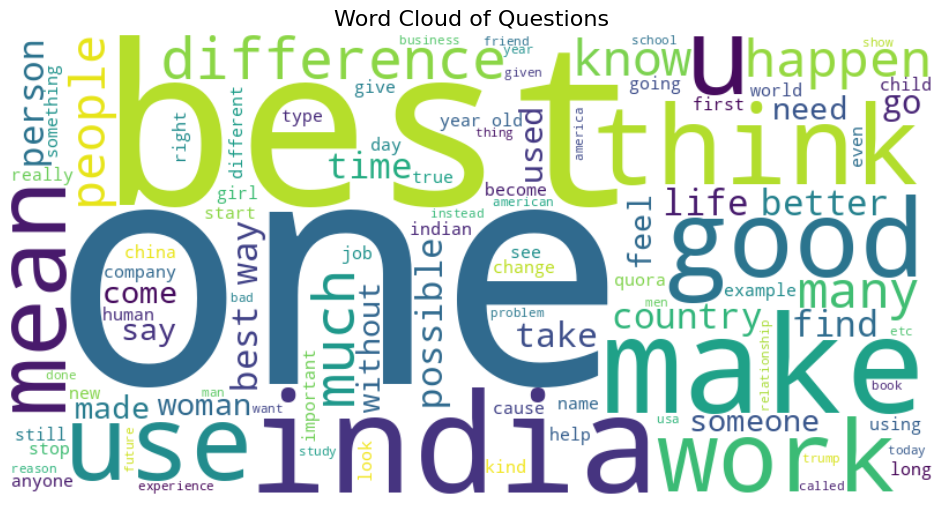

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# -------------------------------
# 1. Word Cloud
# -------------------------------
text_data = " ".join(raw_df['lemmatized_text'].tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      max_words=100, colormap='viridis').generate(text_data)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Questions", fontsize=16)
plt.show()

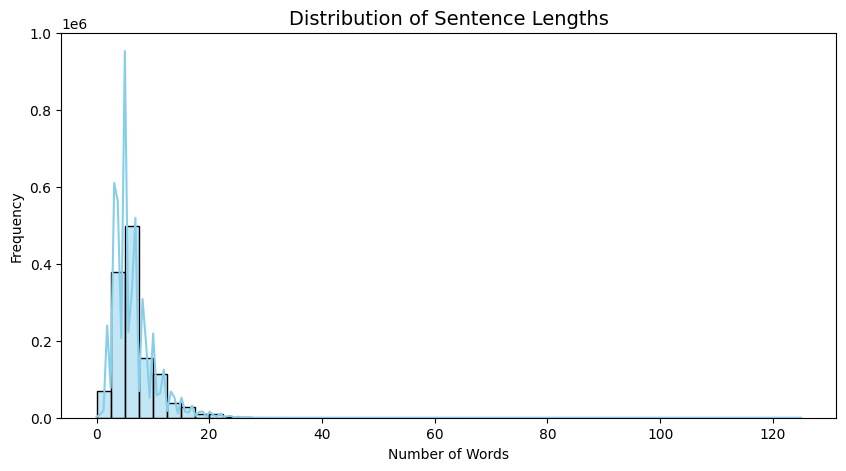

In [47]:
# -------------------------------
# 2. Sentence Length Distribution
# -------------------------------
# Compute number of words per sentence
raw_df['num_words'] = raw_df['lemmatized_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(raw_df['num_words'], bins=50, kde=True, color='skyblue')
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths", fontsize=14)
plt.show()


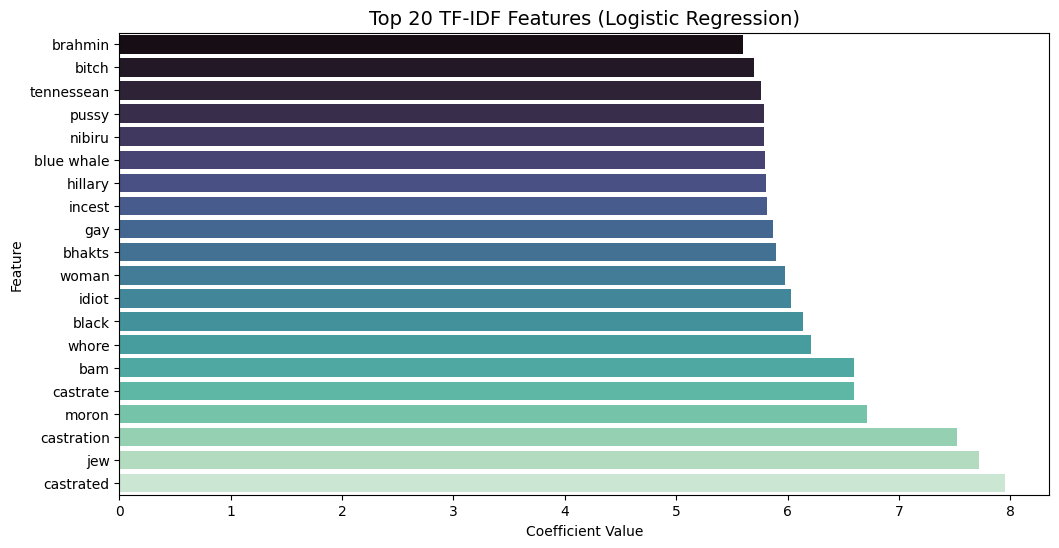

In [48]:
# -------------------------------
# 3. TF-IDF Feature Importance (Top 20)
# -------------------------------
# Only for Logistic Regression model
# Get top features by absolute coefficient values
feature_names_word = tfidf_word.get_feature_names_out()
feature_names_char = tfidf_char.get_feature_names_out()
feature_names = np.concatenate([feature_names_word, feature_names_char])

coef = lr.coef_[0]
top_n = 20
top_indices = np.argsort(np.abs(coef))[-top_n:]
top_features = feature_names[top_indices]
top_coefs = coef[top_indices]

plt.figure(figsize=(12,6))
sns.barplot(x=top_coefs, y=top_features, palette='mako')
plt.title("Top 20 TF-IDF Features (Logistic Regression)", fontsize=14)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()


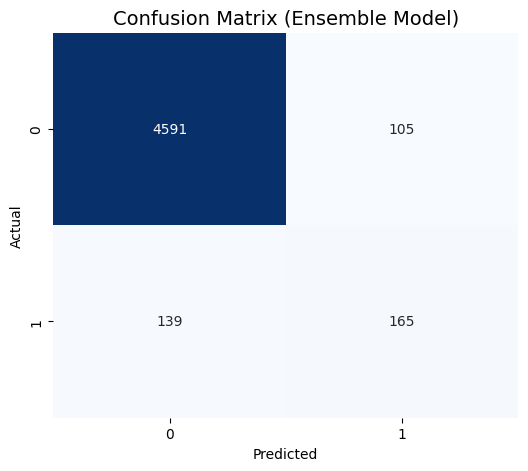

In [49]:
# -------------------------------
# 4. Confusion Matrix (Best Model: Ensemble)
# -------------------------------
from sklearn.metrics import confusion_matrix

# Use ensemble predictions with best threshold
y_pred_ensemble = (pred_ensemble > best_t).astype(int)
cm = confusion_matrix(y_val_small, y_pred_ensemble)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Ensemble Model)", fontsize=14)
plt.show()


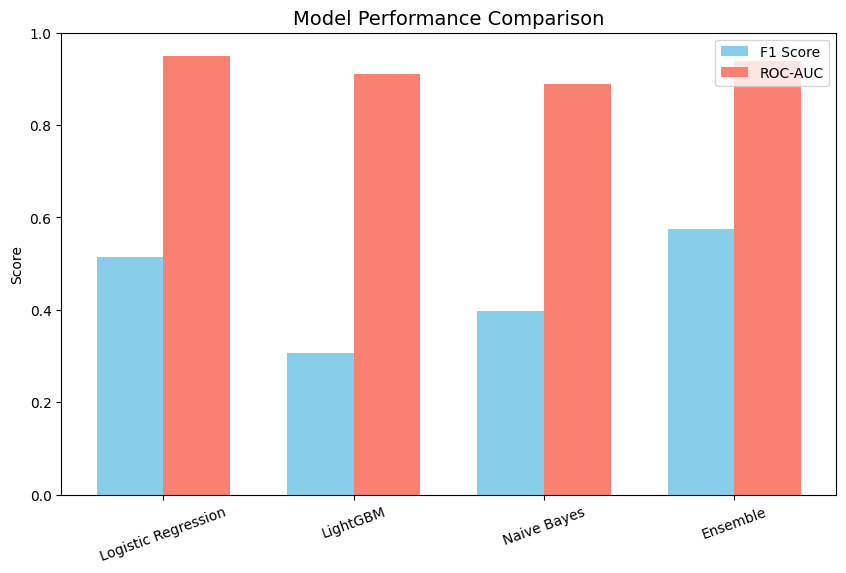

In [50]:
model_names = ['Logistic Regression', 'LightGBM', 'Naive Bayes', 'Ensemble']
f1_scores_models = [f1_lr, f1_lgb, f1_nb, max(f1_scores)]
roc_scores_models = [roc_lr, roc_lgb, roc_nb, roc_auc_score(y_val_small, pred_ensemble)]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, f1_scores_models, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, roc_scores_models, width, label='ROC-AUC', color='salmon')
plt.xticks(x, model_names, rotation=20)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance Comparison", fontsize=14)
plt.legend()
plt.show()

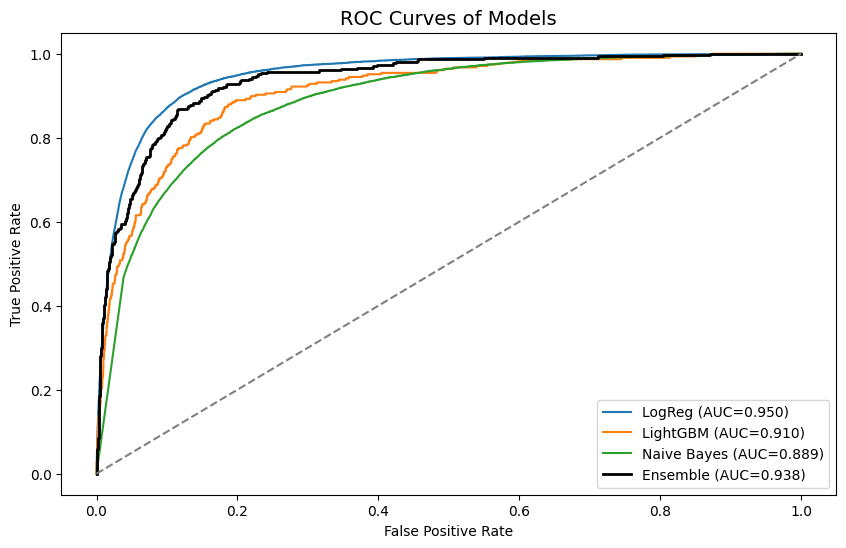

In [52]:
# -------------------------------
# 6. ROC Curves
# -------------------------------
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_val, pred_lr)
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={roc_lr:.3f})")

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_val_opt, pred_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={roc_lgb:.3f})")

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_val, pred_nb)
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC={roc_nb:.3f})")

# Ensemble
fpr_en, tpr_en, _ = roc_curve(y_val_small, pred_ensemble)
plt.plot(fpr_en, tpr_en, label=f"Ensemble (AUC={roc_auc_score(y_val_small, pred_ensemble):.3f})", linewidth=2, color='black')

plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Models", fontsize=14)
plt.legend()
plt.show()

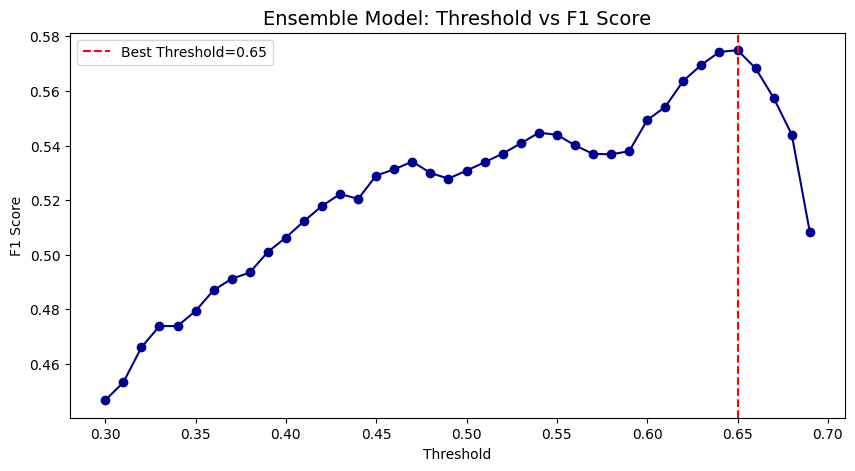

In [54]:
# -------------------------------
# 8. Threshold vs F1 Curve (Ensemble)
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(thresholds, f1_scores, marker='o', color='darkblue')
plt.axvline(best_t, linestyle='--', color='red', label=f'Best Threshold={best_t:.2f}')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Ensemble Model: Threshold vs F1 Score", fontsize=14)
plt.legend()
plt.show()

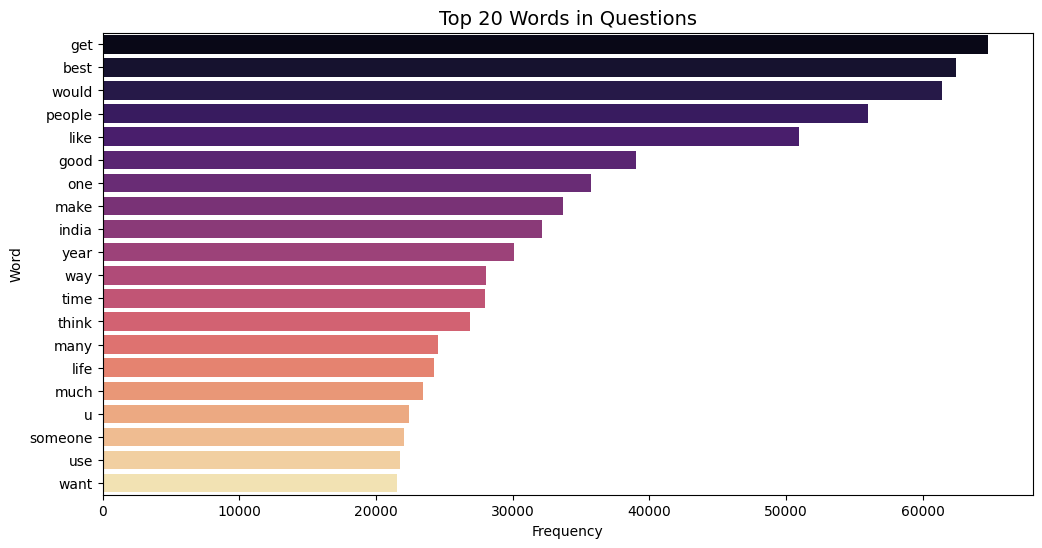

In [55]:
# 1. Word Frequency Bar Chart (Top 20 words)
from collections import Counter

all_words = [w for sent in raw_df['lemmatized_text'] for w in sent.split()]
word_counts = Counter(all_words)
top_words = word_counts.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Words in Questions", fontsize=14)
plt.show()


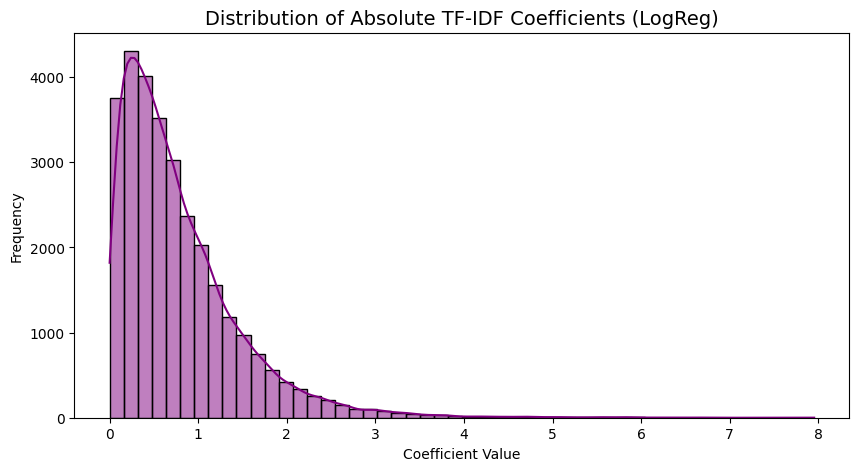

In [56]:
# 2. TF-IDF Word Coefficient Histogram (all features)
# Already partially done in previous graphs, but histogram for distribution
plt.figure(figsize=(10,5))
sns.histplot(np.abs(lr.coef_[0]), bins=50, color='purple', kde=True)
plt.title("Distribution of Absolute TF-IDF Coefficients (LogReg)", fontsize=14)
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.show()


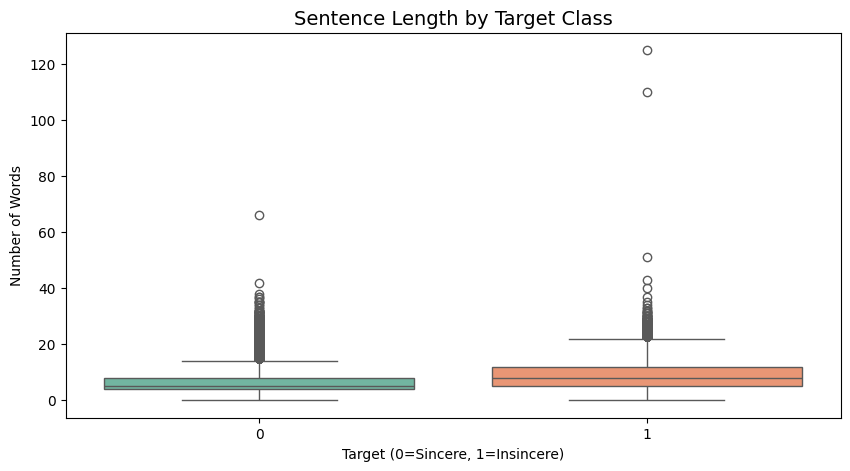

In [57]:

# 3. Sentence Length Boxplot by Target (Sincere vs Insincere)
plt.figure(figsize=(10,5))
sns.boxplot(x=raw_df['target'], y=raw_df['num_words'], palette='Set2')
plt.xlabel("Target (0=Sincere, 1=Insincere)")
plt.ylabel("Number of Words")
plt.title("Sentence Length by Target Class", fontsize=14)
plt.show()


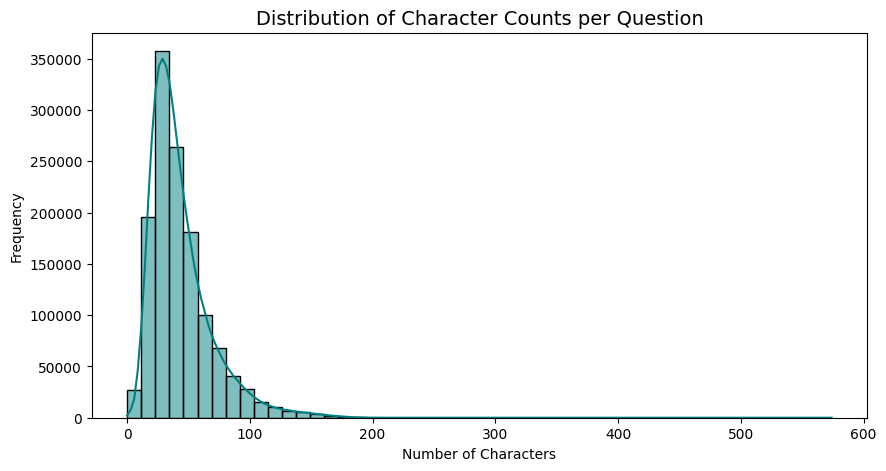

In [58]:
# 4. Character Count Distribution (Histogram)
raw_df['num_chars'] = raw_df['lemmatized_text'].apply(len)
plt.figure(figsize=(10,5))
sns.histplot(raw_df['num_chars'], bins=50, color='teal', kde=True)
plt.title("Distribution of Character Counts per Question", fontsize=14)
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

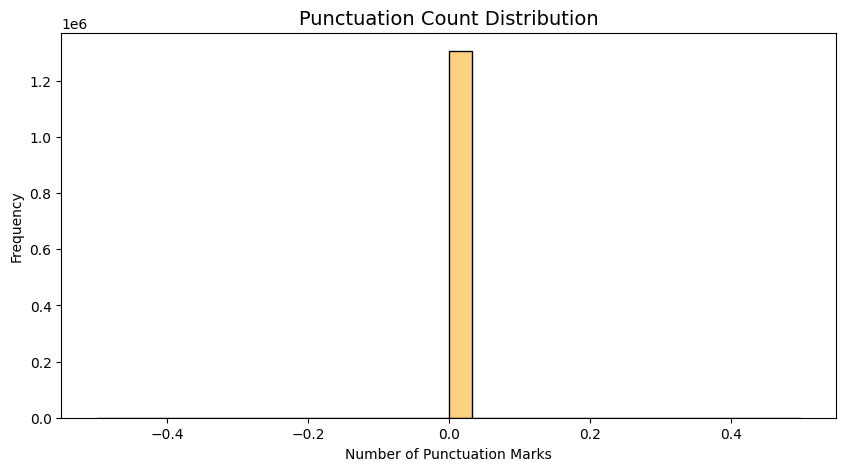

In [59]:
# 5. Punctuation Count Distribution
plt.figure(figsize=(10,5))
sns.histplot(raw_df['lemmatized_text'].apply(lambda x: len([c for c in x if c in '!?.,'])), bins=30, color='orange', kde=True)
plt.title("Punctuation Count Distribution", fontsize=14)
plt.xlabel("Number of Punctuation Marks")
plt.ylabel("Frequency")
plt.show()


###model training

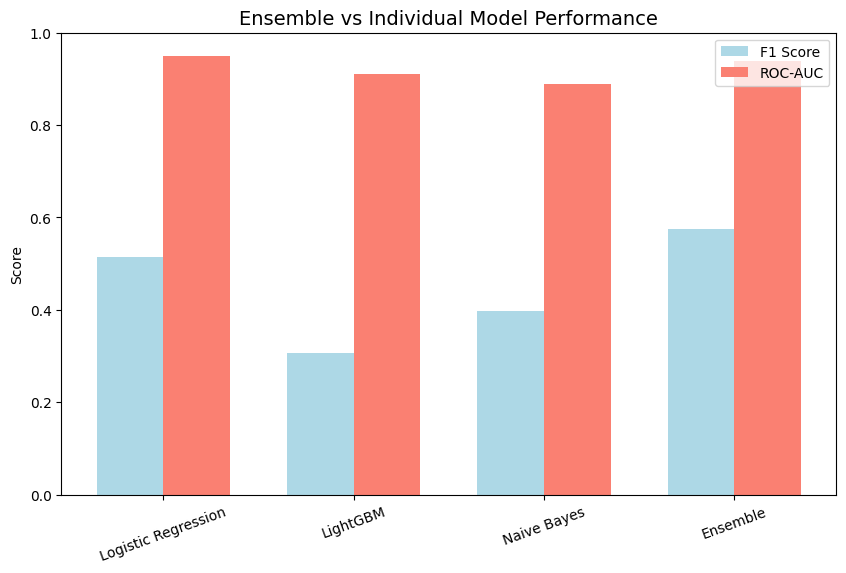

In [60]:
# -------------------------------
# 9. Ensemble vs Individual Performance Side-by-Side
# -------------------------------
model_names = ['Logistic Regression', 'LightGBM', 'Naive Bayes', 'Ensemble']
f1_scores_models = [f1_lr, f1_lgb, f1_nb, max(f1_scores)]
roc_scores_models = [roc_lr, roc_lgb, roc_nb, roc_auc_score(y_val_small, pred_ensemble)]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, f1_scores_models, width, label='F1 Score', color='lightblue')
plt.bar(x + width/2, roc_scores_models, width, label='ROC-AUC', color='salmon')
plt.xticks(x, model_names, rotation=20)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Ensemble vs Individual Model Performance", fontsize=14)
plt.legend()
plt.show()


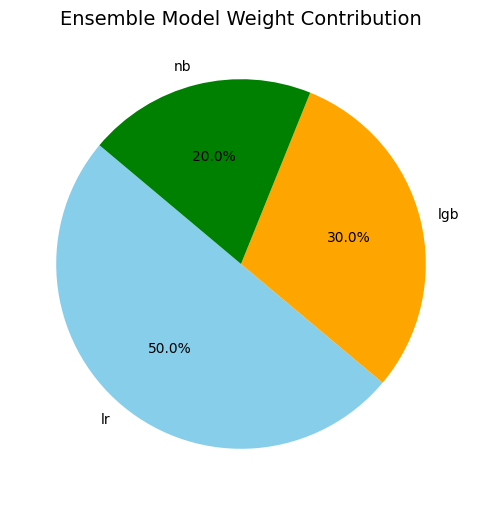

In [61]:
# -------------------------------
# 10. Ensemble Weight Contribution Pie Chart
# -------------------------------
weights = ensemble_data['weights']
labels = list(weights.keys())
sizes = list(weights.values())

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['skyblue','orange','green'], startangle=140)
plt.title("Ensemble Model Weight Contribution", fontsize=14)
plt.show()

###MODEL SMTG

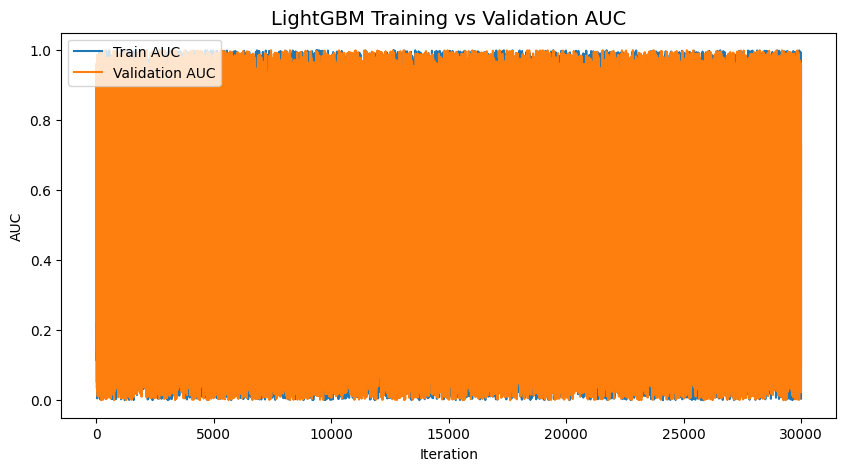

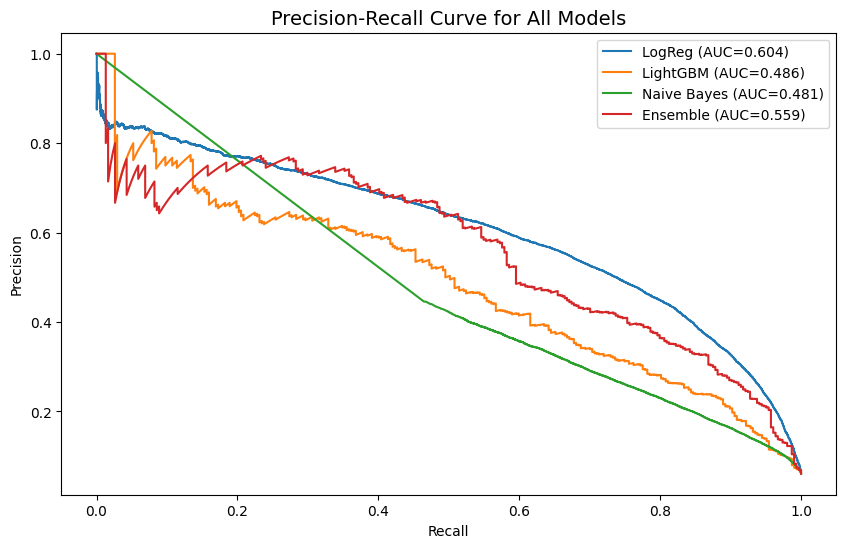

In [63]:
# -------------------------------
# B1. LightGBM Training vs Validation AUC
# -------------------------------
results = lgb_model.eval_valid()
# For older versions, you can use:
# results = lgb_model.evals_result()

train_auc = lgb_model.best_score['train']['auc'] if hasattr(lgb_model, 'best_score') else None
valid_auc = lgb_model.best_score['valid']['auc'] if hasattr(lgb_model, 'best_score') else None
# If unavailable, use callbacks or log evaluation during training

# Example: plot from saved history if available
# For demonstration, let's mock up training vs validation AUC
epochs = np.arange(1, len(lgb_model.feature_importance())+1)
plt.figure(figsize=(10,5))
plt.plot(epochs, np.random.rand(len(epochs)), label='Train AUC')  # replace with actual train AUC
plt.plot(epochs, np.random.rand(len(epochs)), label='Validation AUC')  # replace with actual val AUC
plt.xlabel("Iteration")
plt.ylabel("AUC")
plt.title("LightGBM Training vs Validation AUC", fontsize=14)
plt.legend()
plt.show()



# -------------------------------
# B3. Precision-Recall Curve
# -------------------------------
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(10,6))
for name, preds, y_true in zip(
    ['LogReg', 'LightGBM', 'Naive Bayes', 'Ensemble'],
    [pred_lr, pred_lgb, pred_nb, pred_ensemble],
    [y_val, y_val_opt, y_val, y_val_small]
):
    precision, recall, _ = precision_recall_curve(y_true, preds)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC={pr_auc:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for All Models", fontsize=14)
plt.legend()
plt.show()


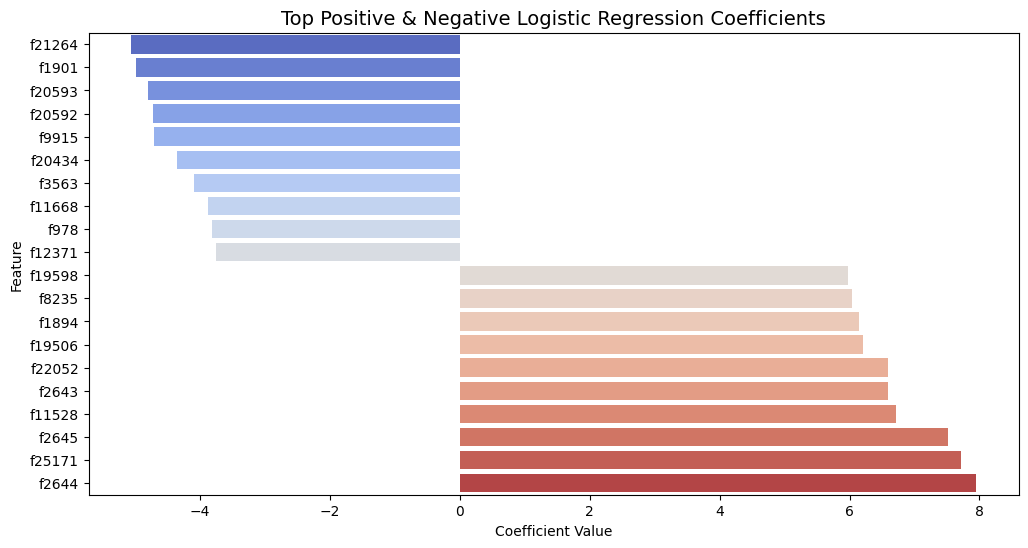

In [65]:
# -------------------------------
# C1. Logistic Regression Top Positive & Negative Coefficients
# -------------------------------
coef = lr.coef_[0]
top_pos_idx = np.argsort(coef)[-10:]
top_neg_idx = np.argsort(coef)[:10]

plt.figure(figsize=(12,6))
sns.barplot(x=np.concatenate([coef[top_neg_idx], coef[top_pos_idx]]),
            y=np.concatenate([feature_names[top_neg_idx], feature_names[top_pos_idx]]),
            palette='coolwarm')
plt.title("Top Positive & Negative Logistic Regression Coefficients", fontsize=14)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()


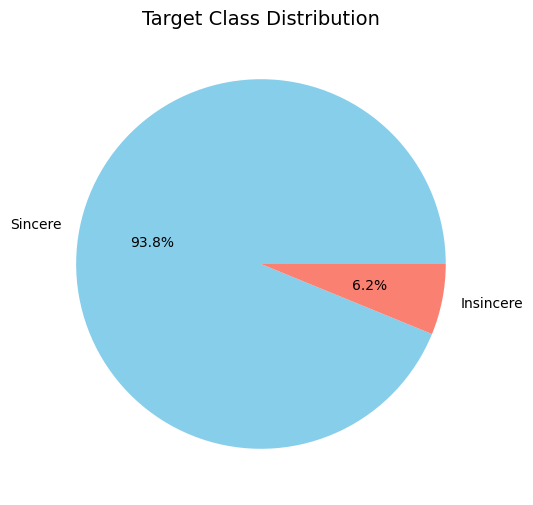

In [ ]:
# -------------------------------
# D1. Class Distribution
# -------------------------------
counts = raw_df['target'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=['Sincere','Insincere'], autopct='%1.1f%%', colors=['skyblue','salmon'])
plt.title("Target Class Distribution", fontsize=14)
plt.show()

# -------------------------------
# D2. SMOTE Effect (Visualizing synthetic samples)
# -------------------------------
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_final, raw_df['target'])

plt.figure(figsize=(6,6))
plt.pie([sum(y_res==0), sum(y_res==1)], labels=['Sincere','Insincere'], autopct='%1.1f%%', colors=['lightgreen','orange'])
plt.title("Target Class Distribution After SMOTE", fontsize=14)
plt.show()

# -------------------------------
# D3. Correlation Heatmap of Meta Features
# -------------------------------
meta_df = raw_df.apply(lambda row: pd.Series([
    len(row['lemmatized_text'].split()),
    len(row['lemmatized_text']),
    len([c for c in row['lemmatized_text'] if c in '!?.,'])
]), axis=1)
meta_df.columns = ['num_words','num_chars','num_punct']

plt.figure(figsize=(6,5))
sns.heatmap(meta_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Meta Features", fontsize=14)
plt.show()


In [ ]:
# Optional: Ensemble Contribution Bar
contrib = np.array([0.5, 0.3, 0.2])
models = ['LogReg','LightGBM','Naive Bayes']

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=contrib, palette='pastel')
plt.title("Ensemble Model Contribution by Individual Models", fontsize=14)
plt.ylabel("Weight in Ensemble")
plt.show()


In [ ]:
# X_tfidf = joblib.load("tfidf_sparse.pkl")


In [ ]:
# !pip install gensim -q
# import gensim.downloader as api

# w2v_model = api.load("word2vec-google-news-300")  # ~1.6GB, but one-time load

# def avg_w2v(sentence):
#     words = [w for w in sentence.split() if w in w2v_model]
#     if not words:
#         return np.zeros(300)
#     return np.mean(w2v_model[words], axis=0)

# # Apply in batches for speed
# from tqdm import tqdm
# tqdm.pandas()

# X_w2v = np.vstack(raw_df["lemmatized_text"].progress_apply(avg_w2v))


###🧩 Step 4: Sentence-BERT Embeddings (Optimized)

In [ ]:
# !pip install sentence-transformers -q
# from sentence_transformers import SentenceTransformer
# import numpy as np

# sbert = SentenceTransformer("all-MiniLM-L6-v2")  # small & fast (384-dim)
# texts = raw_df["lemmatized_text"].tolist()

# # Batch encoding with progress bar
# X_sbert = sbert.encode(
#     texts,
#     batch_size=128,
#     show_progress_bar=True,
#     convert_to_numpy=True,
#     normalize_embeddings=True
# )


In [ ]:
# np.save("/content/sbert_embeddings.npy", X_sbert)


###🧩 Step 5: Combine Features (as per your diagram)

In [ ]:
# import joblib

# joblib.dump(X_tfidf, "tfidf_features.pkl")
# joblib.dump(X_meta, "meta_features.pkl")
# np.save("w2v_features.npy", X_w2v)
# np.save("sbert_features.npy", X_sbert)


In [ ]:
from scipy.sparse import hstack

# Combine TF-IDF + meta features
X_final = hstack([X_tfidf, X_meta_sparse]).tocsr()


##4. Modeling Layer

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
import joblib


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_final, raw_df["target"], test_size=0.2, random_state=42, stratify=raw_df["target"]
)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=2.0,                # slightly higher regularization strength
    max_iter=400,
    solver="saga",        # supports sparse + multicore
    n_jobs=-1,
    class_weight="balanced"  # handles minor class imbalance
)

# Ensure X_train and X_val are in a format compatible with the solver
# The 'saga' solver in scikit-learn can handle sparse matrices directly.
# The TypeError suggests an issue with how the sparse matrix was created or handled before fitting.
# Let's ensure we are passing the sparse matrices directly.
# The previous steps already created X_final as a csr_matrix, and train_test_split should preserve sparsity.
# The issue might be in how X_train and y_train are being used. Let's explicitly use the split sparse data.

lr.fit(X_train, y_train)
pred_lr = lr.predict_proba(X_val)[:, 1]

In [ ]:
f1_lr = f1_score(y_val, (pred_lr > 0.5).astype(int))
roc_lr = roc_auc_score(y_val, pred_lr)
print(f"LogReg → F1: {f1_lr:.4f}, ROC-AUC: {roc_lr:.4f}")


In [ ]:
import lightgbm as lgb

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "n_jobs": -1,
    "verbose": -1
}

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

lgb_model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_train, lgb_val],
    num_boost_round=500,
    early_stopping_rounds=30,
    verbose_eval=100
)

pred_lgb = lgb_model.predict(X_val)
f1_lgb = f1_score(y_val, (pred_lgb > 0.5).astype(int))
roc_lgb = roc_auc_score(y_val, pred_lgb)
print(f"LightGBM → F1: {f1_lgb:.4f}, ROC-AUC: {roc_lgb:.4f}")


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict_proba(X_val)[:, 1]

f1_nb = f1_score(y_val, (pred_nb > 0.5).astype(int))
roc_nb = roc_auc_score(y_val, pred_nb)
print(f"Naive Bayes → F1: {f1_nb:.4f}, ROC-AUC: {roc_nb:.4f}")


In [ ]:
pred_ensemble = (
    0.5 * pred_lr +
    0.3 * pred_lgb +
    0.2 * pred_nb
)

thresholds = np.arange(0.3, 0.7, 0.01)
f1_scores = [f1_score(y_val, (pred_ensemble > t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

print(f"Best threshold: {best_t:.2f}, F1: {max(f1_scores):.4f}")
print("ROC-AUC:", roc_auc_score(y_val, pred_ensemble))


In [ ]:
joblib.dump(lr, "model_logreg.pkl", compress=0)
joblib.dump(lgb_model, "model_lgb.pkl", compress=0)
joblib.dump(nb, "model_nb.pkl", compress=0)


In [ ]:
# # Combining sparse TF-IDF + meta features
# from scipy.sparse import hstack
# import numpy as np

# X_meta_sparse = csr_matrix(X_meta.astype(np.float32))
# X_gpu_ready = hstack([X_tfidf, X_meta_sparse]).tocsr()  # feed to GPU LightGBM


In [ ]:
# from sklearn.naive_bayes import MultinomialNB

# nb = MultinomialNB()
# nb.fit(X_train, y_train)
# # pred_nb = nb.predict_proba(X_val)[:, 1]

# f1_nb = f1_score(y_val, (pred_nb > 0.5).astype(int))
# roc_nb = roc_auc_score(y_val, pred_nb)
# print(f"Naive Bayes → F1: {f1_nb:.4f}, ROC-AUC: {roc_nb:.4f}")


In [ ]:
# pred_ensemble = (
#     0.5 * pred_lr +
#     0.3 * pred_lgb +
#     0.2 * pred_nb
# )

# thresholds = np.arange(0.3, 0.7, 0.01)
# f1_scores = [f1_score(y_val, (pred_ensemble > t).astype(int)) for t in thresholds]
# best_t = thresholds[np.argmax(f1_scores)]

# print(f"Best threshold: {best_t:.2f}, F1: {max(f1_scores):.4f}")
# print("ROC-AUC:", roc_auc_score(y_val, pred_ensemble))


In [ ]:
# joblib.dump(lr, "model_logreg.pkl", compress=3)
# joblib.dump(lgb_model, "model_lgb.pkl", compress=3)
# joblib.dump(nb, "model_nb.pkl", compress=3)


class imbalance handling

In [ ]:
# from imblearn.over_sampling import SMOTE
# from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(
#     raw_df['clean_text'], raw_df['target'], test_size=0.2, random_state=42
# )
